In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader
import math

### 导入数据集

In [89]:
Training_data = datasets.MNIST(root="data", train=True, download=True, transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32,scale = True),v2.Normalize((0.5,), (0.5,))]))
batch_size = 128
Train_dataloader = DataLoader(Training_data, batch_size=batch_size,shuffle=True)


In [71]:
for X , y in Train_dataloader:
    print(X.shape)
    print(y.shape)
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])


### flow model

In [87]:
import torch
import torch.nn as nn

class SimpleTimeEmbedding(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim
        # 一个简单的两层全连接网络，把时间特征提炼一下
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        # t 的形状是 [Batch_Size]
        device = t.device
        half_dim = self.dim // 2
        # 以下是正弦编码的经典数学公式，你不用深究，它就是负责把 1 个数变成 64 个数
        frequencies = torch.exp(
            torch.arange(half_dim, device=device) * -(torch.log(torch.tensor(10000.0)) / (half_dim - 1))
        )
        args = t[:, None] * frequencies[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.mlp(embedding) # 输出形状: [Batch_Size, 64]

In [90]:
class FourierTimeEmbedding(nn.Module):
    def __init__(self, dim=64, wmin=1.0, wmax=1000.0):
        super().__init__()
        self.dim = dim
        # 预先计算好频率 w_i，这些是固定好的，不需要网络去训练（不需要梯度）
        half_dim = dim // 2
        
        # 论文公式 (69) 的对数空间实现方式：wi = wmin * (wmax/wmin) ** (i / (d/2 - 1))
        # 这样可以得到从 wmin 到 wmax 按指数级递增的各种频率
        frequencies = torch.exp(
            torch.linspace(math.log(wmin), math.log(wmax), half_dim)
        )
        # 将频率存为 buffer，这样它会随模型一起移动到 GPU/CPU，但不会被当做参数更新
        self.register_buffer("frequencies", frequencies)

    def forward(self, t):
        # t 的形状假设是 [batch_size]，比如 [32]
        # 1. 扩展维度变成 [batch_size, 1]
        t = t.unsqueeze(-1) 
        
        # 2. 计算 2 * pi * w_i * t
        # self.frequencies 形状是 [32]，相乘利用广播机制得到 [batch_size, 32]
        phases = 2 * math.pi * t * self.frequencies
        
        # 3. 分别计算 cos 和 sin
        cos_emb = torch.cos(phases)
        sin_emb = torch.sin(phases)
        
        # 4. 拼接成 64 维向量
        emb = torch.cat([cos_emb, sin_emb], dim=-1)
        
        # 5. 对应论文公式 (68) 前面的系数：sqrt(2/d)，保证模长为 1
        emb = emb * math.sqrt(2.0 / self.dim)
        
        return emb # 返回 [batch_size, 64]

In [91]:
class FlowModel(nn.Module):
    def __init__(self):
        super(FlowModel, self).__init__()
        self.time_embedding = FourierTimeEmbedding(dim=64)
        self.nn = nn.Sequential(
            nn.Linear(848, 1024),
            nn.SiLU(),
            nn.Linear(1024, 1024),
            nn.SiLU(),
            nn.Linear(1024, 1024),
            nn.SiLU(),
            nn.Linear(1024, 784),
            
        )

    def forward(self, x, t):
        t_emb = self.time_embedding(t)  # [Batch_Size, 64]
        x_and_t = torch.cat([x, t_emb], dim=1)  # [Batch_Size, 784 + 64 = 848]
        return self.nn(x_and_t)  # [Batch_Size, 784]

In [92]:
if __name__ == "__main__":
    # 模拟一个 Batch 有 4 张图片，每张图片 784 维
    mock_images = torch.randn(4, 784) 
    # 模拟 4 张图片各自对应的时间（在 0 到 1 之间）
    mock_times = torch.tensor([0.0, 0.3, 0.7, 1.0]) 
    
    # 实例化你的网络
    model = FlowModel()
    
    # 喂给网络
    predictions = model(mock_images, mock_times)
    
    print("输入图片的形状:", mock_images.shape)
    print("网络输出的形状:", predictions.shape)

输入图片的形状: torch.Size([4, 784])
网络输出的形状: torch.Size([4, 784])


### 采样

In [93]:
def flow_matching(z):
    e = torch.randn_like(z)  # 假设 x_0 是从标准正态分布采样的
    t = torch.rand(z.size(0))  # 随机采样
    t_2d = t[:, None]  # 扩展维度以便广播
    t_2d = t_2d.to(z.device)  # 确保 t 在同一个设备上
    x_t= (1-t_2d)* e + t_2d * z  # 线性插值
    u = (z - e)
    return t, x_t, u



### 训练

In [94]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

def train(model, dataloader, epochs, loss_fn=loss_fn, optimizer=optimizer):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, _) in enumerate(dataloader):
            data = data.view(data.size(0), -1)  # 展平图片
            optimizer.zero_grad()
            
    
            t, x_t, u = flow_matching(data)
            
            # 前向传播
            predictions = model(x_t, t)
            
            # 计算损失
            loss = loss_fn(predictions, u)
            loss.backward()
            optimizer.step()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}], Loss: {loss.item():.4f}")



In [95]:
train(model, Train_dataloader, epochs=20)

Epoch [1/20], Batch [0], Loss: 1.9283
Epoch [1/20], Batch [100], Loss: 1.2707
Epoch [1/20], Batch [200], Loss: 1.2117
Epoch [1/20], Batch [300], Loss: 1.1783
Epoch [1/20], Batch [400], Loss: 1.1923
Epoch [2/20], Batch [0], Loss: 1.1663
Epoch [2/20], Batch [100], Loss: 1.1736
Epoch [2/20], Batch [200], Loss: 1.1681
Epoch [2/20], Batch [300], Loss: 1.1503
Epoch [2/20], Batch [400], Loss: 1.1449
Epoch [3/20], Batch [0], Loss: 1.1329
Epoch [3/20], Batch [100], Loss: 1.1183
Epoch [3/20], Batch [200], Loss: 1.0919
Epoch [3/20], Batch [300], Loss: 1.0878
Epoch [3/20], Batch [400], Loss: 1.0654
Epoch [4/20], Batch [0], Loss: 1.0704
Epoch [4/20], Batch [100], Loss: 1.0417
Epoch [4/20], Batch [200], Loss: 1.0426
Epoch [4/20], Batch [300], Loss: 1.0223
Epoch [4/20], Batch [400], Loss: 1.0000
Epoch [5/20], Batch [0], Loss: 0.9901
Epoch [5/20], Batch [100], Loss: 0.9858
Epoch [5/20], Batch [200], Loss: 0.9853
Epoch [5/20], Batch [300], Loss: 0.9578
Epoch [5/20], Batch [400], Loss: 0.9600
Epoch [6/2

In [ ]:
model.eval()
torch.save(model.state_dict(), "models/flow_model.pth")
torch.no_grad()
time_step = torch.linspace(0, 1, steps=100)  # 生成 100 个时间步
x = torch.randn(1, 784)  # 从标准正态分布采样一个初始点

for t in time_step:
    t = torch.tensor([t])  # 转换为张量
    u = model(x, t)  # 预测速度场
    dt = 0.01  # 假设每个时间步的长度为 0.01
    x = x + u * dt  # 更新位置



In [97]:
x_reshaped = x.view(28, 28)  # 将 784 维向量重新变为 28x28 的图片   
x_reshaped = (x_reshaped - x_reshaped.min()) / (x_reshaped.max() - x_reshaped.min())  # 归一化到 [0, 1]


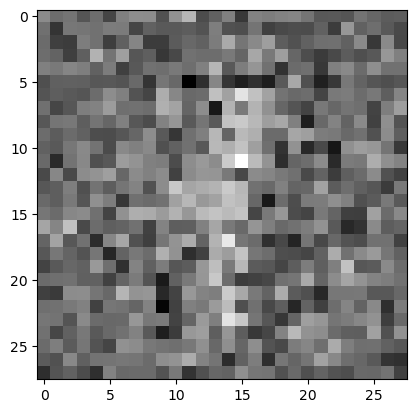

In [98]:
import matplotlib.pyplot as plt
plt.imshow(x_reshaped.cpu().detach().numpy(), cmap='gray')